# Oasis Infobyte Data Science Internship — Task 5
## Sales Prediction Using Python

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA VISULIZATION

In [5]:
df = pd.read_csv("Advertising.csv")

df = df.loc[:, ~df.columns.astype(str).str.startswith("Unnamed")]

display(df.head())
print("Shape:", df.shape)
print("Columns:", list(df.columns))

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


Shape: (200, 4)
Columns: ['TV', 'radio', 'newspaper', 'sales']


Data quality check

In [6]:
print("Missing values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("Duplicate rows:", df.duplicated().sum())

print("\nDescriptive statistics:")
display(df.describe())

Missing values:


,Missing Values
TV,0
radio,0
newspaper,0
sales,0


Duplicate rows: 0

Descriptive statistics:


,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


Pairplot

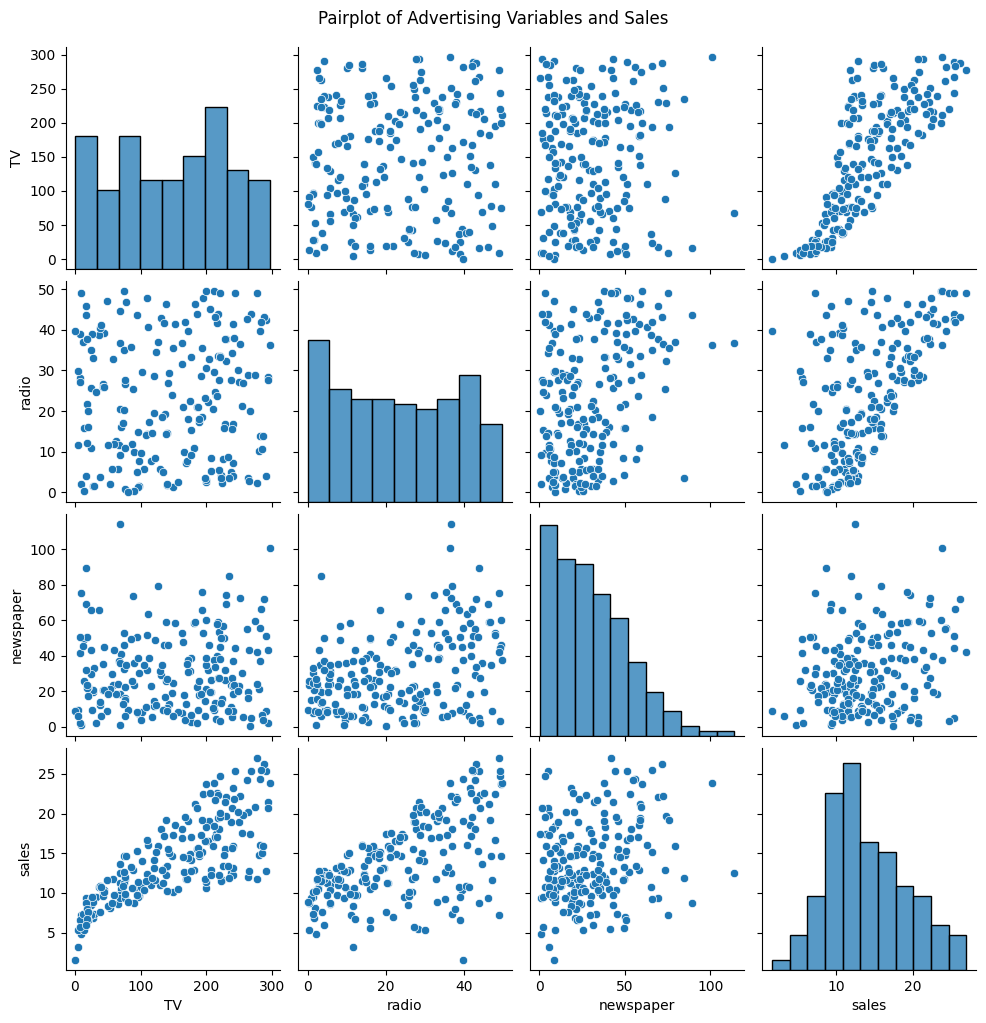

In [7]:
sns.pairplot(df)
plt.suptitle("Pairplot of Advertising Variables and Sales", y=1.02)
plt.show()

Individual scatter plots

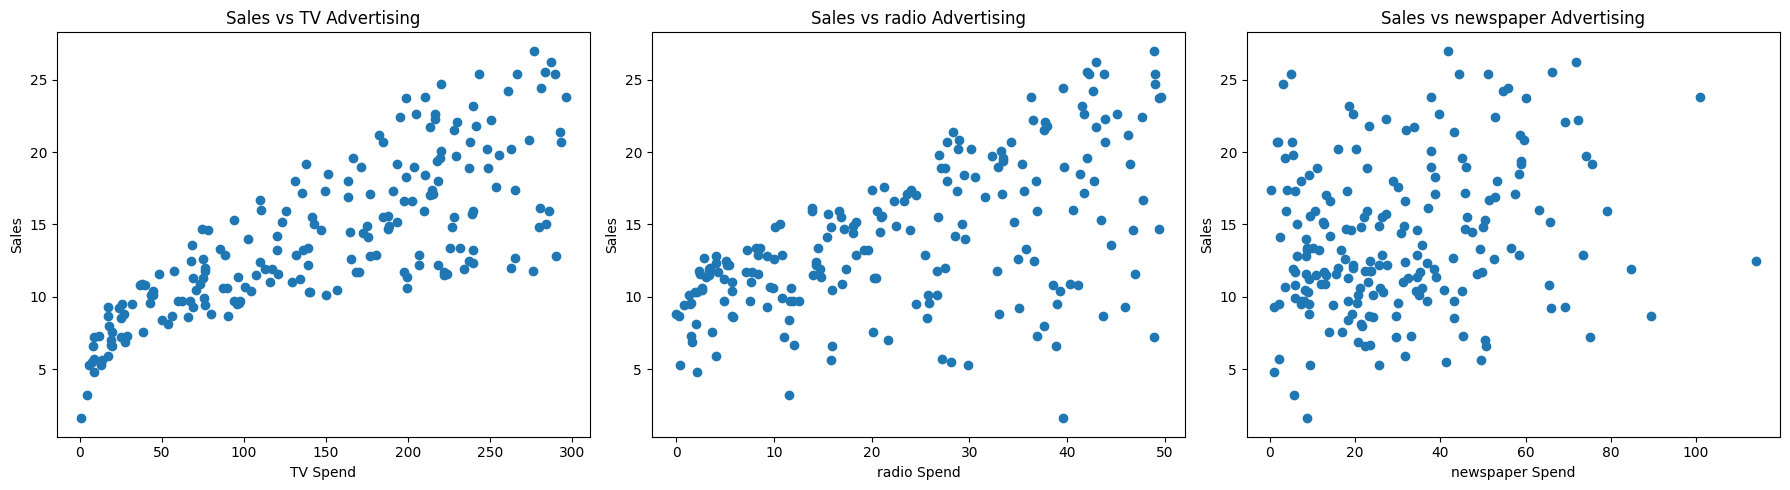

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, ["TV", "radio", "newspaper"]):
    ax.scatter(df[feature], df["sales"])
    ax.set_title(f"Sales vs {feature} Advertising")
    ax.set_xlabel(f"{feature} Spend")
    ax.set_ylabel("Sales")

plt.tight_layout()
plt.show()

Correlation heatmap

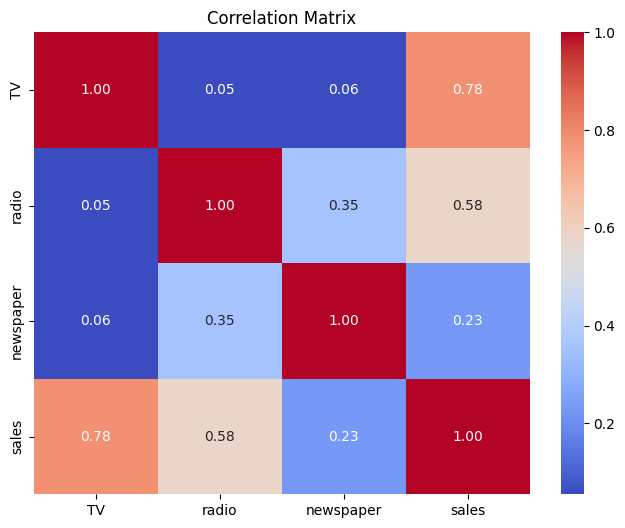

In [11]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

Prepare machine learning data

In [18]:
X = df[["TV", "radio", "newspaper"]]
y = df["sales"]

Spiliting DATA SET

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

Linear Regression

In [20]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)
linear_mae = mean_absolute_error(y_test, linear_pred)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_pred)
)

linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression")
print(f"MAE : {linear_mae:.4f}")
print(f"RMSE: {linear_rmse:.4f}")
print(f"R²  : {linear_r2:.4f}")

Linear Regression
MAE : 1.4608
RMSE: 1.7816
R²  : 0.8994


Second model

In [23]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Regressor")
print(f"MAE : {rf_mae:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"R²  : {rf_r2:.4f}")

Random Forest Regressor
MAE : 0.6131
RMSE: 0.7403
R²  : 0.9826


Compare the models

In [24]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2": [
        linear_r2,
        rf_r2
    ]
})

display(results.sort_values("RMSE"))

,Model,MAE,RMSE,R2
1,Random Forest,0.613075,0.740335,0.982635
0,Linear Regression,1.460757,1.781600,0.899438


Actual vs predicted graph

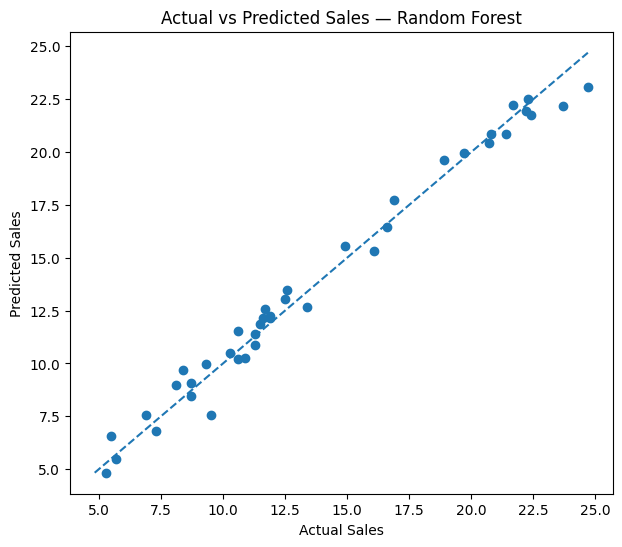

In [25]:
best_pred = rf_pred if rf_rmse < linear_rmse else linear_pred
best_name = "Random Forest" if rf_rmse < linear_rmse else "Linear Regression"

plt.figure(figsize=(7, 6))

plt.scatter(y_test, best_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title(
    f"Actual vs Predicted Sales — {best_name}"
)

low = min(y_test.min(), best_pred.min())
high = max(y_test.max(), best_pred.max())

plt.plot(
    [low, high],
    [low, high],
    linestyle="--"
)

plt.show()

Residual analysis

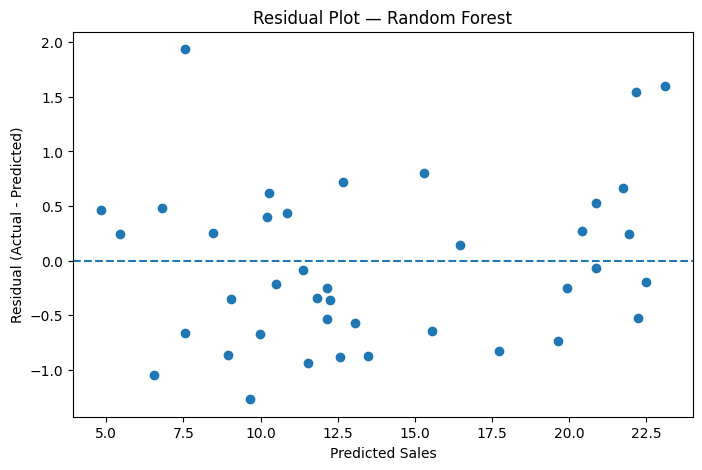

In [26]:
residuals = y_test - best_pred

plt.figure(figsize=(8, 5))

plt.scatter(best_pred, residuals)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Sales")
plt.ylabel("Residual (Actual - Predicted)")

plt.title(
    f"Residual Plot — {best_name}"
)

plt.show()

Find the most important advertising channel

,Channel,Linear Regression Coefficient
1,radio,0.189195
0,TV,0.044730
2,newspaper,0.002761


,Channel,Random Forest Importance
0,TV,0.625447
1,radio,0.361745
2,newspaper,0.012808


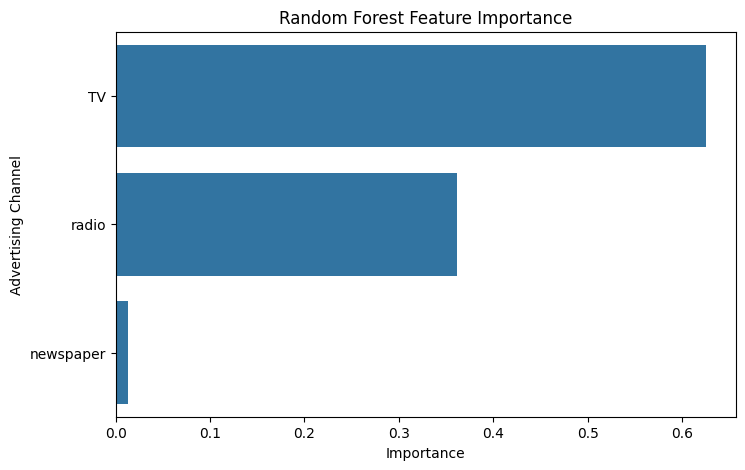

In [29]:
coef_df = pd.DataFrame({
    "Channel": X.columns,
    "Linear Regression Coefficient": linear_model.coef_
}).sort_values(
    "Linear Regression Coefficient",
    ascending=False
)

display(coef_df)
importance_df = pd.DataFrame({
    "Channel": X.columns,
    "Random Forest Importance": rf_model.feature_importances_
}).sort_values(
    "Random Forest Importance",
    ascending=False
)

display(importance_df)
plt.figure(figsize=(8, 5))

sns.barplot(
    data=importance_df,
    x="Random Forest Importance",
    y="Channel"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Advertising Channel")

plt.show()